# 02 · Retrieval ablation — correct / permuted / zero (Experiment 2)
**Question:** does the improvement depend on using the *correct* fMRI?

This is the decisive control. `fMRI correct` must clearly beat `permuted` and `zero`.

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do — this avoids a notebooks/data/... mismatch.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
from src.data import FmriDataModule
from src.models import build_model_from_checkpoint
from src.evaluation import evaluate_ablation, conclusion_from_summary, topk_candidates
from src.utils import get_device

cfg = load_config('configs/exp02_retrieval_ablation.yaml')
device = get_device(cfg.get('runtime.device','auto'))
dm = FmriDataModule(cfg).prepare()
ckpt = 'outputs/exp01_fmri_to_clip/checkpoints/best.pt'
model, _ = build_model_from_checkpoint(cfg, ckpt, device, dm.voxel_counts)

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion
18:59:52 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
18:59:52 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}


In [2]:
res = evaluate_ablation(model, cfg, dm, split='test',
                        conditions=['correct','permuted','zero'], device=device)
summary = res['summary']
summary[summary.subject_id=='all'].pivot_table(index='metric_name', columns='condition', values='value')

condition,correct,permuted,zero
metric_name,,,
retrieval/mean_cosine,0.535740,0.270339,0.016176
retrieval/mean_rank,3.459119,79.723270,80.000000
retrieval/median_rank,2.000000,81.000000,80.000000
retrieval/top1,0.471698,0.000000,0.006289
retrieval/top10,0.955975,0.044025,0.062893
retrieval/top5,0.867925,0.012579,0.031447


## Top-k by condition

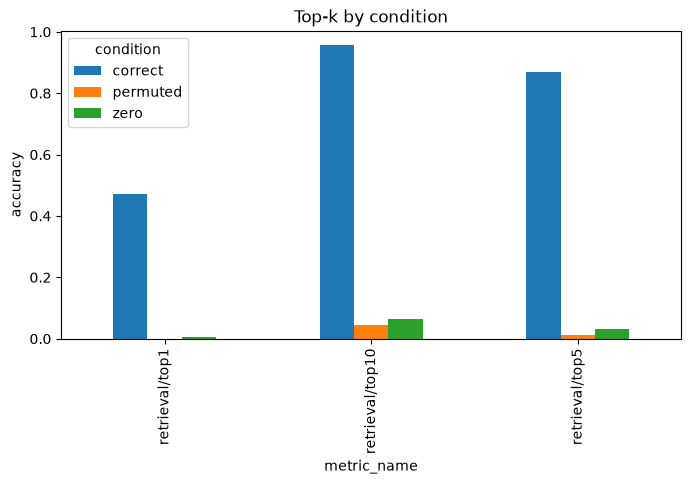

condition,correct,permuted,zero
metric_name,,,
retrieval/top1,0.471698,0.000000,0.006289
retrieval/top10,0.955975,0.044025,0.062893
retrieval/top5,0.867925,0.012579,0.031447


In [3]:
piv = summary[(summary.subject_id=='all') & (summary.metric_name.str.startswith('retrieval/top'))]
piv = piv.pivot_table(index='metric_name', columns='condition', values='value')
piv.plot(kind='bar', figsize=(8,4)); plt.ylabel('accuracy'); plt.title('Top-k by condition'); plt.show()
piv

## Qualitative retrieval (correct condition)

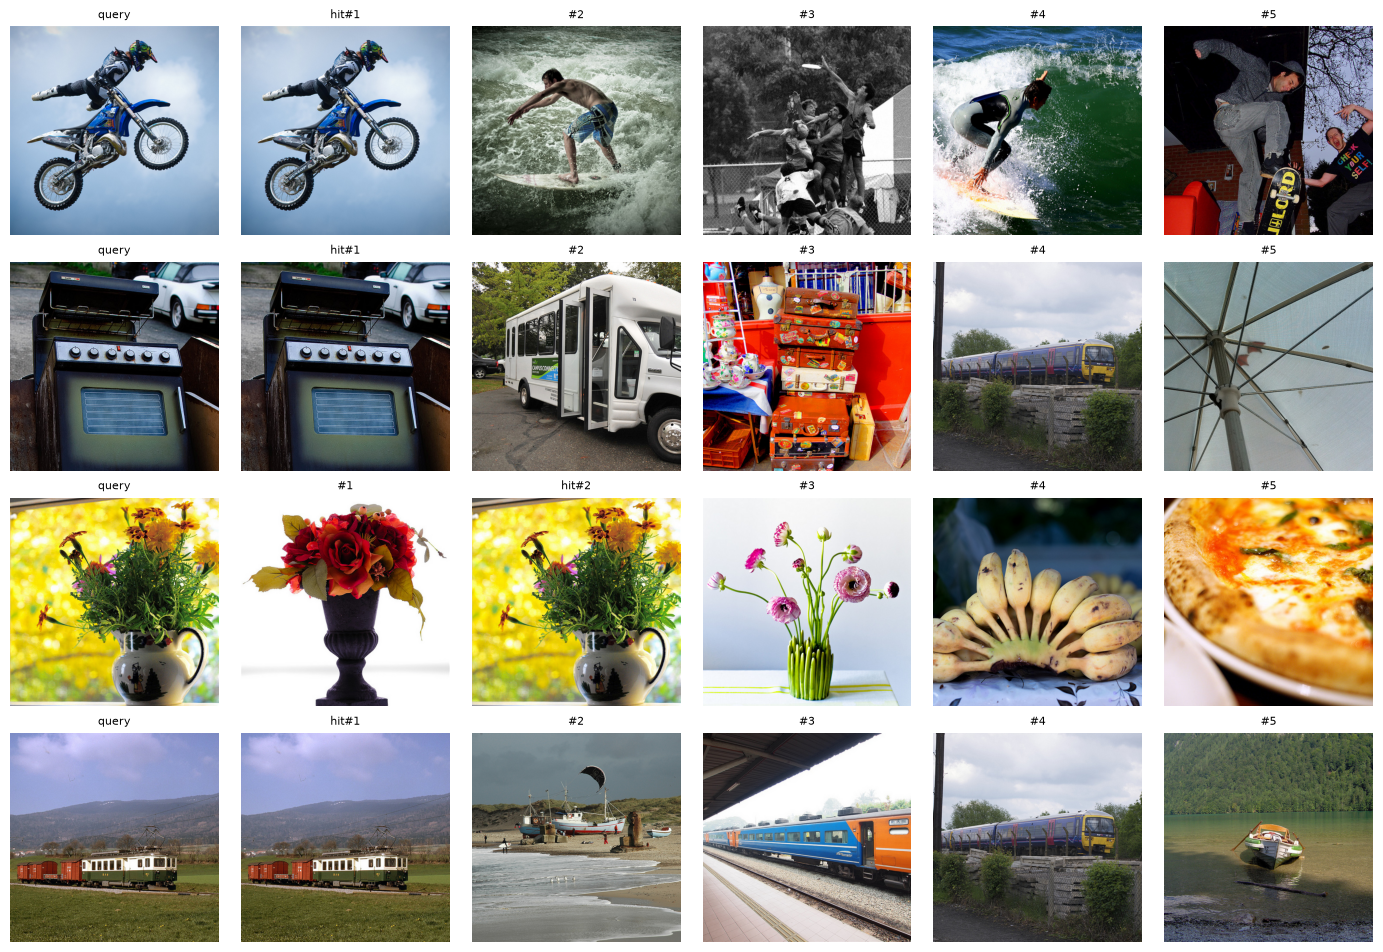

In [4]:
pred = res['predictions']['correct'][dm.subjects[0]]
cand = topk_candidates(pred['clip_pred'], pred['clip_target'], k=5)
from src.data import load_image
paths_ = pred['image_paths']
n_show = min(4, len(paths_))
fig, axes = plt.subplots(n_show, 6, figsize=(14, 2.4*n_show))
for r in range(n_show):
    axes[r,0].imshow(load_image(paths_[r])); axes[r,0].set_title('query', fontsize=8); axes[r,0].axis('off')
    for j, ci in enumerate(cand[r]):
        axes[r,j+1].imshow(load_image(paths_[ci]))
        axes[r,j+1].set_title(('hit' if ci==r else '')+f'#{j+1}', fontsize=8); axes[r,j+1].axis('off')
plt.tight_layout(); plt.show()

In [5]:
concl = conclusion_from_summary(summary, metric='retrieval/top5', subject='all')
print(concl['message']); concl

fMRI correcto supera claramente a los controles


{'decision': 'fmri_used',
 'metric': 'retrieval/top5',
 'subject': 'all',
 'correct': 0.8679245283018868,
 'best_control': 0.031446540880503145,
 'margin': 1.0,
 'values': {'correct': 0.8679245283018868,
  'permuted': 0.012578616352201259,
  'zero': 0.031446540880503145},
 'message': 'fMRI correcto supera claramente a los controles'}

**Takeaway:** if `correct` does not clearly exceed `permuted`/`zero`, we must NOT claim the model uses real brain information (spec §2, §8.5).